# Advanced Matplotlib for Physics

This notebook follows up on the basics of `matplotlib`. We will explore more powerful techniques that give you greater control over your plots. These methods are essential for creating complex, publication-quality figures for lab reports and research papers.

## The "Clean" Object-Oriented Way Revisited

In the previous session, you were briefly introduced to the object-oriented approach. Instead of calling `plt.plot()` for everything, we first create a **figure** and one or more **axes** objects:

`fig, ax = plt.subplots()`

- `fig`: This is the entire figure, like the canvas you draw on. You can use it to save the plot or change its overall size.
- `ax`: This is the actual subplot where the data is plotted. It holds all the elements like the x- and y-axis, lines, and labels. 

From then on, you use methods of the `ax` object to build the plot, such as `ax.plot()`, `ax.set_xlabel()`, `ax.grid()`, etc. This approach is more explicit and organized, which is incredibly helpful when you start creating figures with multiple plots.

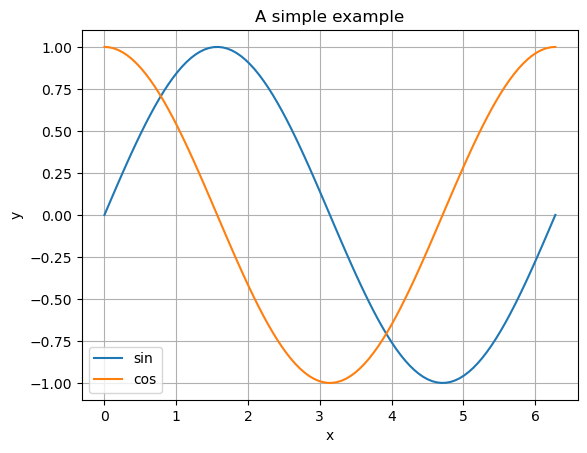

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# A simple example: Plotting sin and cos

x = np.linspace(0, 2*np.pi, 100)

# 1. Create a figure and an axes object
fig, ax = plt.subplots()

# 2. Use the 'ax' object for plotting 
ax.plot(x, np.sin(x), label = "sin")
ax.plot(x, np.cos(x), label = "cos")

ax.set_title('A simple example')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.grid(True)
ax.legend()

# 3. Show the plot
plt.show()


<span style="background-color: #f8bbd0; color: black; padding: 2px 5px; border-radius: 3px;">**Task 10.1**</span> A projectile is fired with an initial velocity $v_0 = 50$ m/s at an angle $\theta = 30^{\circ}$. The position is given by: $x(t) = v_0 \cos(\theta) \cdot t$ and $y(t) = v_0 \sin(\theta) \cdot t - \frac{1}{2}gt^2$
(where $g = 9.81$ m/s²).

Using the object-oriented approach, plot the trajectory of the projectile (y vs. x) for times from $t=0$ to $t=5.1$ seconds. Add a title and axis labels.

In [5]:
# Constants
v0 = 50  # m/s
theta = np.deg2rad(30)  # Angle in radians
g = 9.81  # m/s^2

# Time array
t = np.linspace(0, 5.1, 100)

# Calculate x and y coordinates
x = v0 * np.cos(theta) * t
y = v0 * np.sin(theta) * t - 0.5 * g * t**2

# Your solution here
# 1. Create fig, ax

# 2. Plot y vs x on ax

# 3. Set title and labels

# 4. Show the plot


## Multiple Subplots

The real power of the object-oriented approach shines when you need multiple plots in one figure. You can create a grid of subplots by passing `nrows` and `ncols` to `plt.subplots()`.

`fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(6, 8))`

This creates a figure with 3 rows and 1 column of plots. `axs` is now a NumPy array of axes objects. You can access each one by its index (e.g., `axs[0]`, `axs[1]`). For a 2D grid, you'd use two indices (e.g., `axs[0, 1]`). `figsize` is an optional argument to control the figure size in inches.

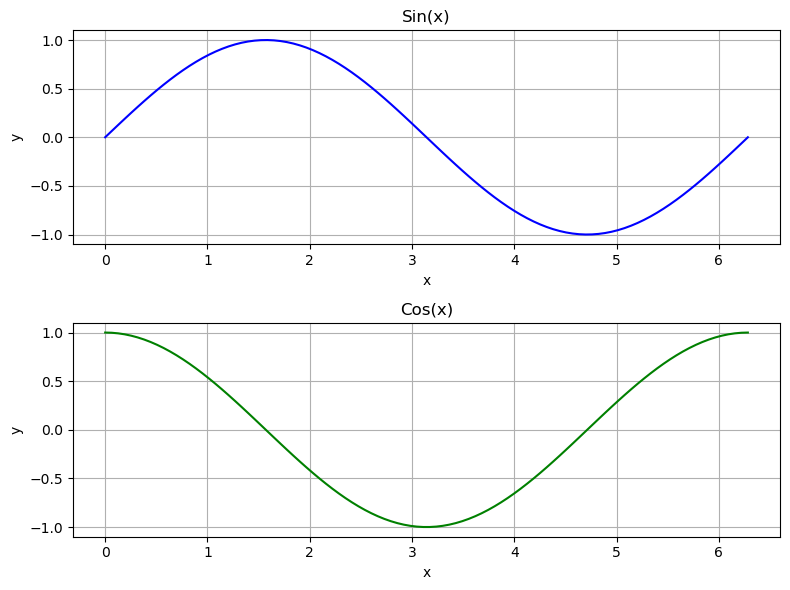

In [7]:
# Example: Position, Velocity, and Acceleration in Simple Harmonic Motion
x = np.linspace(0, 2*np.pi, 100)

# Create a 3x1 grid of subplots. `sharex=True` links the x-axes.
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(8, 6))

# Plot on the first axes
axs[0].plot(x, np.sin(x), color='blue')
axs[0].set_ylabel('y')
axs[0].set_xlabel('x')
axs[0].set_title('Sin(x)')
axs[0].grid()


# Plot on the second axes
axs[1].plot(x, np.cos(x), color='green')
axs[1].set_ylabel('y')
axs[1].set_xlabel('x')
axs[1].grid()
axs[1].set_title('Cos(x)')

plt.tight_layout() # Adjusts plots to prevent labels from overlapping
plt.show()

<span style="background-color: #f8bbd0; color: black; padding: 2px 5px; border-radius: 3px;">**Task 10.2**</span> Using the projectile motion data from **Task 10.1**, create a figure with two subplots stacked horizontally (`nrows=1, ncols=2`).

1.  **Top plot (`axs[0]`):** Plot the projectile's trajectory (y vs. x).
2.  **Bottom plot (`axs[1]`):** Plot the projectile's height over time (y vs. t).

Make sure to add appropriate titles and labels to each subplot. Can you find a way to label the y-axis only once (share y-axis)?

In [9]:
# Constants from before
v0 = 50  # m/s
theta = np.deg2rad(30)  # Angle in radians
g = 9.81  # m/s^2

# Your solution here

# Time array

# Calculate x and y coordinates

# 1. Create fig, ax

# 2. Plot y vs x on axs[0]

# 3. Plot y vs t on axs[1]

# 4. Show the plot

## Twin Axes for Different Scales

Sometimes you want to plot two different quantities on the same graph, but they have very different scales or units (e.g., Temperature and Pressure). A twin axis allows you to have a second y-axis on the right side of the plot.

You create it from an existing axes object using `ax2 = ax1.twinx()`. This creates a new axes `ax2` that shares the same x-axis with `ax1`.

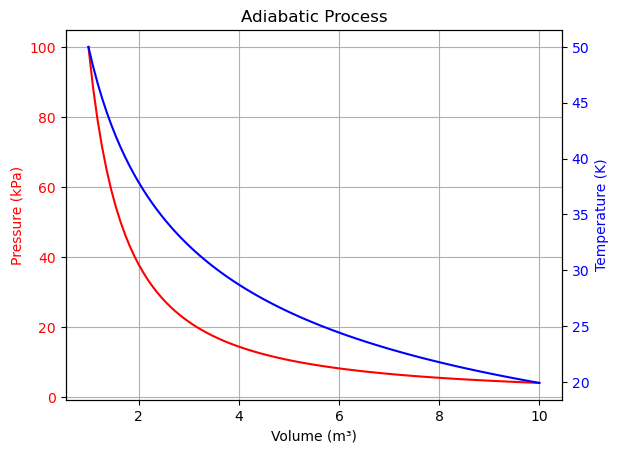

In [11]:
# Example: Temperature and Pressure of a gas during an adiabatic process
V = np.linspace(1, 10, 100) # Volume in m^3
P = 100 * V**(-1.4) # Pressure in kPa
T = 50 * V**(-0.4) # Temperature in Kelvin

fig, ax1 = plt.subplots()

# Plot Pressure on the first y-axis (ax1)
ax1.plot(V, P, color='red', label='Pressure')
ax1.set_xlabel('Volume (m³)')
ax1.set_ylabel('Pressure (kPa)', color='red')
ax1.tick_params(axis='y', labelcolor='red') # format the "ticks" on the first y-axis
ax1.grid()
# Create a second y-axis that shares the x-axis
ax2 = ax1.twinx()

# Plot Temperature on the second y-axis (ax2)
ax2.plot(V, T, color='blue', label='Temperature')
ax2.set_ylabel('Temperature (K)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

ax1.set_title('Adiabatic Process')
plt.show()

<span style="background-color: #f8bbd0; color: black; padding: 2px 5px; border-radius: 3px;">**Task 10.3**</span> An RC circuit has a resistor $R = 1$ M$\Omega$ and a capacitor $C = 5$ µF. The capacitor is initially charged to $V_0 = 10$ V and then discharges. The voltage across the capacitor and the current are given by:
$V_C(t) = V_0 e^{-t/\tau}$
$I(t) = (V_0/R) e^{-t/\tau}$
where the time constant $\tau = RC$.

Plot both the voltage (in V) and the current (in µA) versus time on the same plot using a twin axis. Time should go from 0 to 25 seconds.
- Voltage should be blue and use the left y-axis.
- Current should be red and use the right y-axis.

In [13]:
# Constants
R = 1e6  # 1 MegaOhm
C = 5e-6  # 5 microFarad
V0 = 10  # Volts
tau = R * C

t = np.linspace(0, 25, 200)

# Calculate Voltage and Current
voltage = V0 * np.exp(-t / tau)
current = (V0 / R) * np.exp(-t / tau)
current_microA = current * 1e6 # convert to microamperes for plotting

# Your solution here

# Plot Pressure on the first y-axis (ax1)

# Create a second y-axis that shares the x-axis

# Plot Temperature on the second y-axis (ax2)


## More Plot Types for Data Analysis
Line and scatter plots are fundamental, but physics often requires other types of visualizations to understand data distributions or uncertainties.

### Histograms
Histograms are perfect for visualizing the distribution of a set of measurements. They show how frequently values fall into certain ranges (bins). This is key for studying statistical noise or the distribution of events like radioactive decays.

### Error Bars
No experimental result is complete without its uncertainty! Error bars visually represent this uncertainty on your data points. `ax.errorbar()` is used for this, which creates a scatter or line plot with error bars attached.

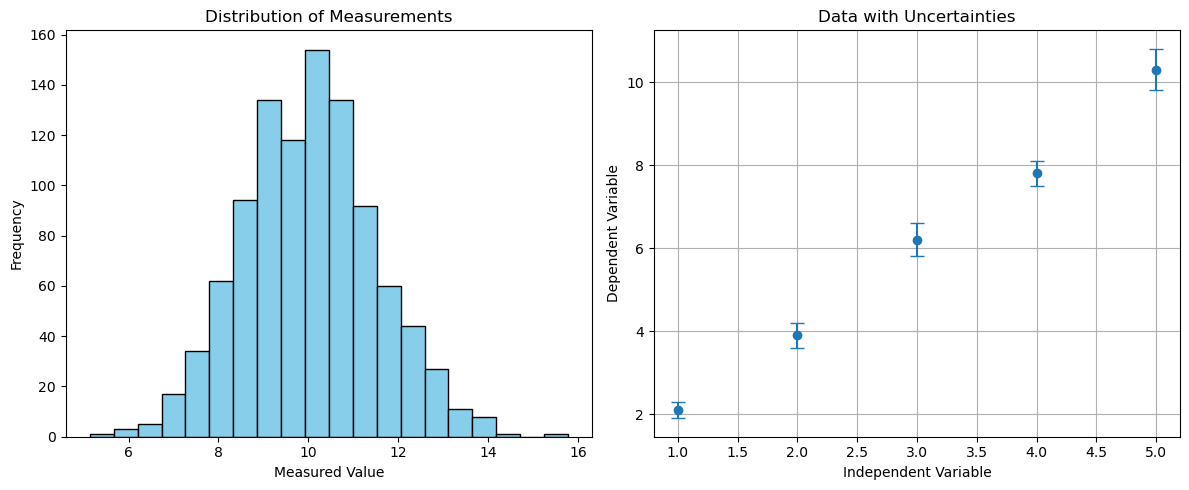

In [15]:
# Generate some example data
np.random.seed(42) # for reproducibility
measurements = np.random.normal(loc=10.0, scale=1.5, size=1000) # 1000 measurements with mean 10 and std 1.5

x_data = np.array([1, 2, 3, 4, 5])
y_data = np.array([2.1, 3.9, 6.2, 7.8, 10.3])
y_error = np.array([0.2, 0.3, 0.4, 0.3, 0.5]) # Uncertainty in y

# Create a 1x2 grid of subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
axs[0].hist(measurements, bins=20, color='skyblue', edgecolor='black')
axs[0].set_title('Distribution of Measurements')
axs[0].set_xlabel('Measured Value')
axs[0].set_ylabel('Frequency')

# Error Bar Plot
axs[1].errorbar(x_data, y_data, yerr=y_error, fmt='o', capsize=5, label='Experimental Data')
axs[1].set_title('Data with Uncertainties')
axs[1].set_xlabel('Independent Variable')
axs[1].set_ylabel('Dependent Variable')
axs[1].grid(True)

plt.tight_layout()
plt.show()

<span style="background-color: #f8bbd0; color: black; padding: 2px 5px; border-radius: 3px;">**Task 10.4**</span> A university professor wants to analyze the distribution of exam scores for a large class.
It is known that the scores approximately follow a normal distribution with:
Mean (μ) = 75 and Standard deviation (σ) = 10

1. Create a histogram of possible scores to visualize their distribution. Choose a reasonable number of bins (e.g., 25).
2. Add a title and appropriate axis labels.

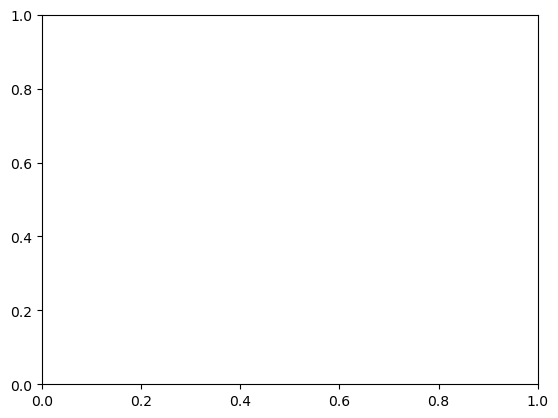

In [17]:
# Simulate data
grades = np.random.normal(loc=75, scale=10, size=100)

fig, ax = plt.subplots()

# Your solution here

# Histogram

# Show the plot

<span style="background-color: #f8bbd0; color: black; padding: 2px 5px; border-radius: 3px;">**Task 10.5**</span> An experiment is conducted to verify Ohm's Law ($V = IR$). The voltage across a resistor is varied, and the current is measured. The data, including uncertainties in the current, is given below.
1. Create a scatter plot of Current vs. Voltage using `ax.errorbar()` to show the uncertainties in the current (`current_error`).
2. Add a title, labels, and a grid.

In [19]:
voltage = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0]) # Volts
current = np.array([0.04, 0.11, 0.14, 0.21, 0.24, 0.31]) # Amperes
current_error = np.array([0.02, 0.02, 0.03, 0.02, 0.03, 0.04]) # Uncertainty in Amperes

# Your solution here

## Customization and Saving Figures

Finally, `matplotlib` offers vast customization options. Two important ones are logarithmic scales and saving figures.

### Logarithmic Scales
For data that spans several orders of magnitude (like in radioactive decay or filter frequency response), a log scale is essential. You can set it with `ax.set_yscale('log')` or `ax.set_xscale('log')`.

### Saving Figures
To save your plot for a report, use the figure object's `savefig` method. You can specify the format (PNG, PDF, SVG) and the resolution (DPI - Dots Per Inch).

`fig.savefig('my_plot.png', dpi=300)`

<span style="background-color: #f8bbd0; color: black; padding: 2px 5px; border-radius: 3px;">**Task 10.6**</span> Plot an exponential function $f(x) = e^{x}$.
1. Change the y-axis (Frequency) to a logarithmic scale. This is often called a "log-lin" plot and is very useful for spotting exponential behavior.
2. If you want, plot two subfigures for the linear and the logarithmic scale respectively.
3. Save the resulting figure as a high-resolution PNG file named `decay_histogram_log.png`.

In [22]:
# Your solution here

# Initialize x-values

# Create function values

# Create figure 

# Make Plot with errorbars

# Save PLot